# Gaussian Data Initialisation

This notebook creates a univariate Gaussian stream with a known abrupt covariate shift:

$$x_i\sim\mathcal{N}(0,1)\quad(i<500),\qquad x_i\sim\mathcal{N}(2,1)\quad(i\geq500).$$

## Project structure

```text
ewma_covariate_shift_demo/
├── README.md
├── notebooks/
│   └── 01_gaussian_data_initialisation.ipynb
├── data/
│   ├── raw/
│   └── processed/
├── src/
│   ├── __init__.py
│   └── ewma.py
├── outputs/
│   └── figures/
└── tests/
    └── __init__.py
```

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

## 1. Define the experiment

In [2]:
N_BEFORE = 500
N_AFTER = 500
SHIFT_POINT = N_BEFORE

MEAN_BEFORE = 0.0
MEAN_AFTER = 2.0
STD_BEFORE = 1.0
STD_AFTER = 1.0

assert N_BEFORE > 0 and N_AFTER > 0
assert STD_BEFORE > 0 and STD_AFTER > 0

print(f"Total observations: {N_BEFORE + N_AFTER}")
print(f"Known shift point: {SHIFT_POINT}")

Total observations: 1000
Known shift point: 500


## 2. Generate the Gaussian stream

In [3]:
pre_shift = rng.normal(MEAN_BEFORE, STD_BEFORE, N_BEFORE)
post_shift = rng.normal(MEAN_AFTER, STD_AFTER, N_AFTER)

values = np.concatenate([pre_shift, post_shift])
time_index = np.arange(values.size)

gaussian_stream = pd.DataFrame({
    "time": time_index,
    "x": values,
    "true_regime": np.where(time_index < SHIFT_POINT, "before_shift", "after_shift"),
    "true_shift": (time_index == SHIFT_POINT).astype(int),
})

gaussian_stream.head()

,time,x,true_regime,true_shift
0,0,0.304717,before_shift,0
1,1,-1.039984,before_shift,0
2,2,0.750451,before_shift,0
3,3,0.940565,before_shift,0
4,4,-1.951035,before_shift,0


## 3. Validate and summarise the generated data

In [4]:
assert len(gaussian_stream) == N_BEFORE + N_AFTER
assert gaussian_stream["true_shift"].sum() == 1
assert gaussian_stream["x"].notna().all()

summary = gaussian_stream.groupby("true_regime")["x"].agg(["count", "mean", "std", "min", "max"])
summary

,count,mean,std,min,max
true_regime,,,,,
after_shift,500,1.955343,1.018376,-1.648413,5.178854
before_shift,500,-0.013126,0.959934,-2.566658,2.913862


## 4. Plot the time series and known shift

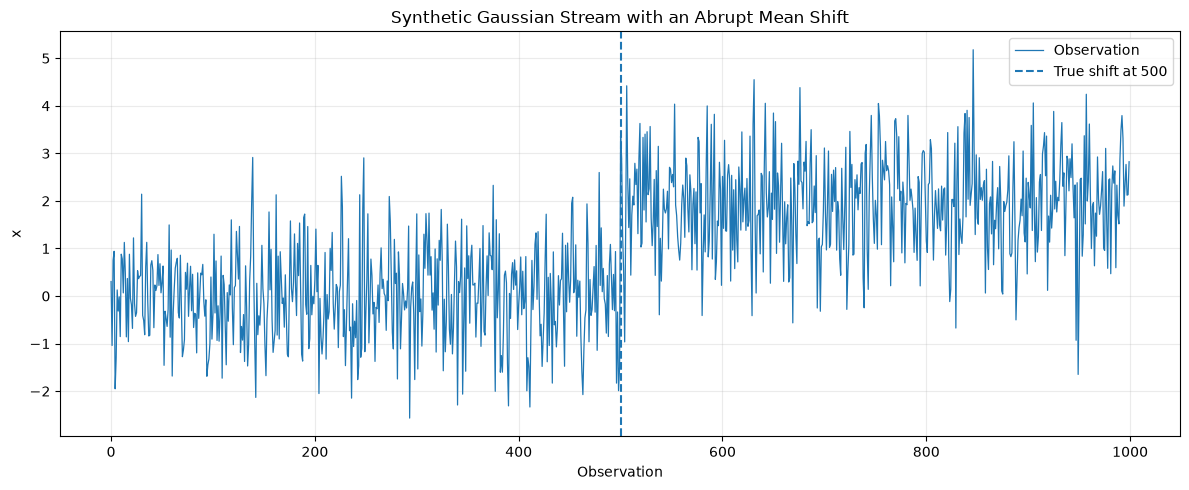

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(gaussian_stream["time"], gaussian_stream["x"], linewidth=0.9, label="Observation")
ax.axvline(SHIFT_POINT, linestyle="--", linewidth=1.5, label=f"True shift at {SHIFT_POINT}")
ax.set_title("Synthetic Gaussian Stream with an Abrupt Mean Shift")
ax.set_xlabel("Observation")
ax.set_ylabel("x")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 5. Compare the pre-shift and post-shift distributions

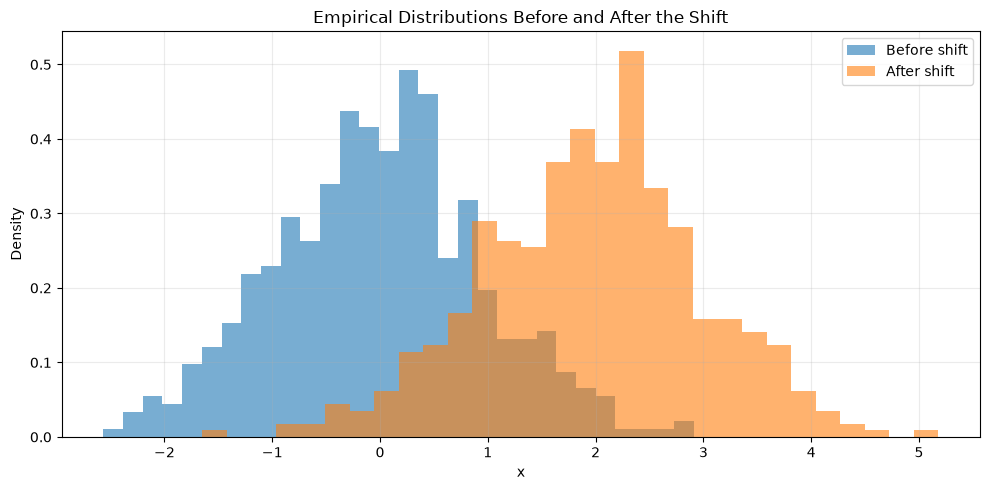

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(pre_shift, bins=30, alpha=0.6, density=True, label="Before shift")
ax.hist(post_shift, bins=30, alpha=0.6, density=True, label="After shift")
ax.set_title("Empirical Distributions Before and After the Shift")
ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 6. Save the raw dataset

In [7]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

output_path = PROJECT_ROOT / "data" / "raw" / "gaussian_mean_shift.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)
gaussian_stream.to_csv(output_path, index=False)
print(f"Saved to: {output_path.resolve()}")
print(f"Dataset shape: {gaussian_stream.shape}")

Saved to: C:\Users\haoch\OneDrive\Desktop\ewma_covariate_shift_demo\ewma_covariate_shift_demo\data\raw\gaussian_mean_shift.csv
Dataset shape: (1000, 4)


## Next stage

The next notebook can add EWMA parameter initialisation, one-step-ahead prediction, moving control limits, Stage-I alarms, and optional Kolmogorov–Smirnov validation.